# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025. N = 2,192 matches (note: Wimbledon 2020 excluded).

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win
5. Olympic interaction regressions

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 2,192 matches | years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 1. Variable Construction

In [2]:
# ── Tiebreak flags ─────────────────────────────────────────────────────────────
# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 ≥ 8): Olympics and Wimbledon post-2018
df['match_tb'] = (df['winners_set3'] >= 8).fillna(False)
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# ── Match structure ────────────────────────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']   # winner came back from 0-1 down

# ── Olympic period flags ───────────────────────────────────────────────────────
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        if t != 'Wimbledon':  # Exclude Wimbledon 2020
            return 'Tokyo Prep'
        else:
            return None  # Exclude Wimbledon 2020
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']   = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)   # Pre-Paris and Paris Prep
df['olympic_period']= df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn']= (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences (winner − loser) ────────────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

# Match-level averages (across both teams)

df['same_country_avg']   = (df['same_country_winners'] + df['same_country_losers']) / 2 
df['same_language_avg']  = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']      = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete.')

Variable construction complete.


## 2. Pressure Outcomes — Counts and Inspection

In [3]:
print('=== Table 1. Pressure Outcome Counts (all matches, N=2,192) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 ≥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=2,192) ===
  Set-1 tiebreak (7-pt)                               N= 530  (24.2%)
  Set-2 tiebreak (7-pt)                               N= 569  (26.0%)
  Set-3 regular tiebreak (7-pt)                       N= 230  (10.5%)
  Match tiebreak / super-tb (10-pt, set3 ≥ 8)         N=  30  (1.4%)
  Any regular tiebreak (sets 1 or 2)                  N= 964  (44.0%)
  Any tiebreak (all types)                            N=1076  (49.1%)
  Match went to 3 sets                                N= 903  (41.2%)
  Comeback wins (winner lost set 1)                   N= 395  (18.0%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  262 0.4520
Olympics          28 0.4380
Roland Garros    201 0.3460
US Open          165 0.4400
Wimbledon        308 0.5200

Match tiebreaks (super-tb) by tournament/year:
                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018   3

### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct — pressure in a closely contested set — but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence

> **Note on 2024-25 sample sizes.** From 2024 onward the Grand Slam draws in the data are larger (134 matches per GS vs. ~62 in earlier years), bringing in more early-round pairs with diverse nationalities. This mechanical composition effect accounts for much of the apparent drop in homophily shares in 2024-25 and should be borne in mind when interpreting the trend.

In [4]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 – Dec 2019', 'Jan 2020 – Jul 2021', 'Aug 2021 – Dec 2022'],
    'GS included': ['AO18–USO19', 'AO20–Wim21 (ex Wim20)', 'USO21–USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 – Dec 2022', 'Jan 2023 – Jul 2024', 'Aug 2024 – Dec 2025'],
    'GS included': ['AO22–USO22', 'AO23–Wim24', 'USO24–USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle — Team composition across period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle — Team composition across period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Winner vs. loser team homophily rates (Grand Slams):')
for vw, vl, lbl in [
    ('same_country_winners', 'same_country_losers',           'Same nationality'),
    ('winners_same_language','losers_same_language',          'Same language'),
    ('winners_linguistic_proximity','losers_linguistic_proximity','Ling. proximity'),
]:
    w, l = 100*gs[vw].mean(), 100*gs[vl].mean()
    print(f'  {lbl:<25s}  winners={w:.1f}%  losers={l:.1f}%  diff={w-l:+.1f} pp')

=== Table 2A. Tokyo 2021 cycle — Team composition across period ===
                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 – Dec 2019             AO18–USO19           40.0000        53.4000          54.3000     1024
Tokyo Prep  Jan 2020 – Jul 2021  AO20–Wim21 (ex Wim20)           41.4000        54.3000          54.3000      374
Post-Tokyo  Aug 2021 – Dec 2022            USO21–USO22           38.3000        52.4000          53.2000      622

=== Table 2B. Paris 2024 cycle — Team composition across period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 – Dec 2022   AO22–USO22           38.6000        52.0000        

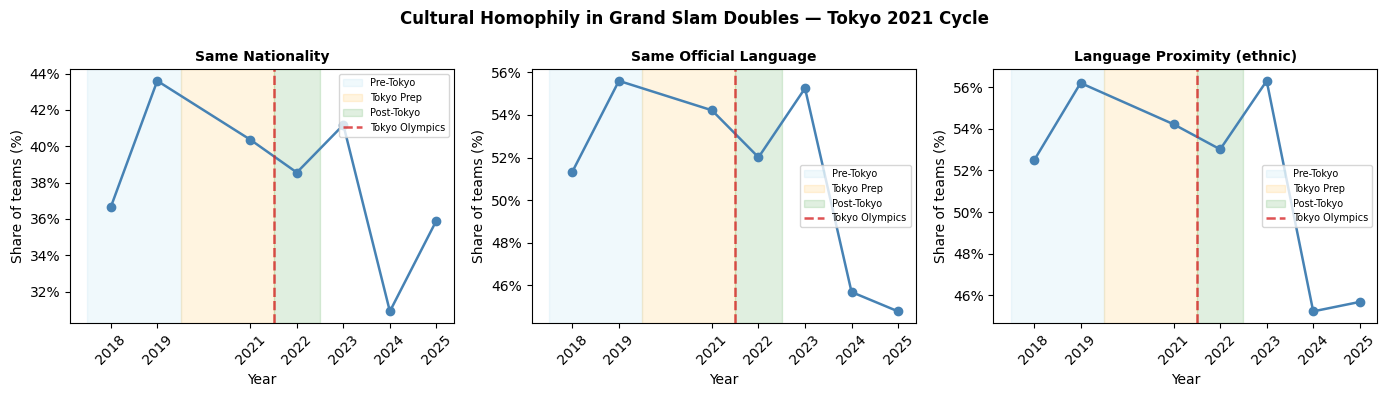

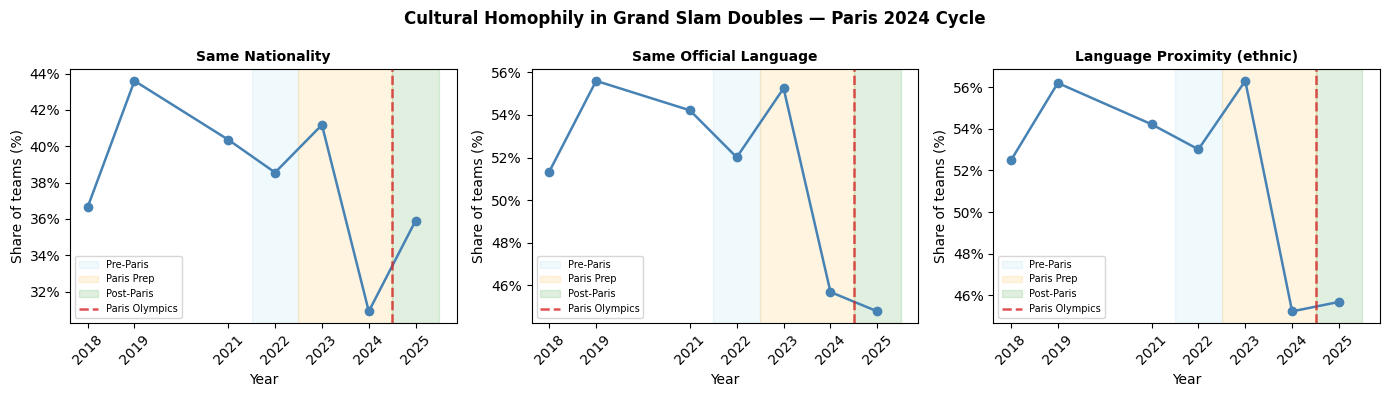

In [5]:
year_means = gs.groupby('year')[hcols].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, col, title in zip(axes, hcols,
    ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']):
    ax.plot(year_means.index, year_means[col], marker='o', color='steelblue', linewidth=1.8, markersize=6)
    ax.axvspan(2017.5, 2019.5, alpha=0.12, color='skyblue', label='Pre-Tokyo')
    ax.axvspan(2019.5, 2021.5, alpha=0.12, color='orange', label='Tokyo Prep')
    ax.axvspan(2021.5, 2022.5, alpha=0.12, color='green', label='Post-Tokyo')
    ax.axvline(2021.5, color='#d62728', linestyle='--', linewidth=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(sorted(gs['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles — Tokyo 2021 Cycle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, col, title in zip(axes, hcols,
    ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']):
    ax.plot(year_means.index, year_means[col], marker='o', color='steelblue', linewidth=1.8, markersize=6)
    ax.axvspan(2021.5, 2022.5, alpha=0.12, color='skyblue', label='Pre-Paris')
    ax.axvspan(2022.5, 2024.5, alpha=0.12, color='orange', label='Paris Prep')
    ax.axvspan(2024.5, 2025.5, alpha=0.12, color='green', label='Post-Paris')
    ax.axvline(2024.5, color='#d62728', linestyle='--', linewidth=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(sorted(gs['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles — Paris 2024 Cycle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [6]:
# Build team panel (match-level → team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb','tb_s3_regular',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_linguistic_proximity'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_linguistic_proximity'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values

# Concatenate and compute derived variables
team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

print(f'Team panel constructed: {len(team_df):,} obs | {len(team_df)//2:,} matches')

Team panel constructed: 4,384 obs | 2,192 matches


## 5. Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Culture measure is entered one at a time; here we use language proximity only.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.


In [7]:
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) | 
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {len(team_gs)//2:,} matches')

Team panel (Grand Slams only): 3,476 obs | 1,738 matches


In [8]:
# Save team_gs to data folder for reuse
output_path = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv'
team_gs.to_csv(output_path, index=False)
print(f'Team panel saved to {output_path}')

Team panel saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv


In [9]:
BASE = '+ ling_prox + rank_mean + opp_rank_mean + rank_gap + single_top100'
FE   = '+ C(tournament):C(year) + C(stage_code)'

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params: continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f'  {prefix}{lbl:<40s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')

vars_main = [
    ('ling_prox',      'Language proximity (ethnic)'),
    ('rank_mean',      'Team average doubles ranking'),
    ('opp_rank_mean',  'Opponent average doubles ranking'),
    ('rank_gap',       'Teammate rank gap'),
    ('single_top100',  'Top-100 singles player'),
]

In [10]:
print('=== Table 3. Match Win — Logit (tournament- year interaction + round FE, SE clustered by match) ===')

logit_win = smf.logit(f'win ~ {BASE} {FE}', data=team_gs).fit(
    cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)

print(f'Logit N={int(logit_win.nobs):,}  Pseudo-R²={logit_win.prsquared:.3f}')
show_vars(logit_win, vars_main, 'Logit ')

=== Table 3. Match Win — Logit (tournament- year interaction + round FE, SE clustered by match) ===
Logit N=3,476  Pseudo-R²=0.066
  Logit Language proximity (ethnic)               +0.2756***  se=0.0722  p=0.000
  Logit Team average doubles ranking              -0.0053***  se=0.0007  p=0.000
  Logit Opponent average doubles ranking          +0.0031***  se=0.0004  p=0.000
  Logit Teammate rank gap                         +0.0014**   se=0.0006  p=0.011
  Logit Top-100 singles player                    +0.0427     se=0.1429  p=0.765


In [11]:
print('=== Table 4. Tiebreak Win — Logit (sample: matches with any tiebreak, 7p/10p) ===')
tb_sub = team_gs[team_gs['any_tb'] == 1].copy()
print(f'N={len(tb_sub):,} team-obs | {len(tb_sub)//2} matches with any tiebreak')

logit_tb = smf.logit(f'won_any_tb ~ {BASE} {FE}', data=tb_sub).fit(
    cov_type='cluster', cov_kwds={'groups': tb_sub['match_id']}, disp=False)

print(f'Logit Pseudo-R²={logit_tb.prsquared:.3f}')
show_vars(logit_tb, vars_main)
print()

=== Table 4. Tiebreak Win — Logit (sample: matches with any tiebreak, 7p/10p) ===
N=1,750 team-obs | 875 matches with any tiebreak
Logit Pseudo-R²=0.025
  Language proximity (ethnic)               +0.0847     se=0.1096  p=0.440
  Team average doubles ranking              -0.0006     se=0.0007  p=0.409
  Opponent average doubles ranking          +0.0011**   se=0.0005  p=0.026
  Teammate rank gap                         -0.0007     se=0.0006  p=0.274
  Top-100 singles player                    -0.1877     se=0.2148  p=0.382



In [12]:
print('=== Table 5. Comeback Win — Logit (3-set Grand Slam matches; conditional on losing set 1) ===')
print('Outcome: team won after losing set 1 (i.e., P(win | lost set 1, 3 sets)).')
print('Regressors: language proximity only + team rank + opponent rank + rank gap + top-100 singles indicator.')

# Comebacks are only possible for teams that lost set 1.
cb_sub = team_gs[(team_gs['three_sets'] == True) & (team_gs['lost_set1'] == 1)].copy()
print(f'Raw sample: N={len(cb_sub):,} team-obs | {len(cb_sub)//2:,} matches')
print(f'Raw conditional win rate={100*cb_sub["win"].mean():.1f}%')

# Keep tournament×year FE, but drop tournament×year cells with no within-cell outcome variation.
cb_sub['ty'] = cb_sub['tournament'].astype(str) + '__' + cb_sub['year'].astype(int).astype(str)
_ty_nuniq = cb_sub.groupby('ty')['win'].nunique()
keep_ty = _ty_nuniq[_ty_nuniq == 2].index
cb_sub = cb_sub[cb_sub['ty'].isin(keep_ty)].copy()

print(f'After dropping non-informative tournament×year cells: N={len(cb_sub):,} team-obs | {len(cb_sub)//2:,} matches')
print(f'Conditional win rate={100*cb_sub["win"].mean():.1f}%')

# Estimate with tournament×year FE encoded as C(ty). Use the same culture measure specification as the other tables.
for fe_try, label in [
    ('+ C(ty) + C(stage_code)', 'tournament×year FE + stage FE'),
    ('+ C(ty)', 'tournament×year FE'),
]:
    try:
        logit_cb = smf.logit(f'win ~ {BASE} {fe_try}', data=cb_sub).fit(
            cov_type='cluster', cov_kwds={'groups': cb_sub['match_id']}, disp=False, maxiter=200)
        print(f'FE used: {label}')
        break
    except Exception as e:
        last_err = e
else:
    raise last_err

print(f'Logit Pseudo-R²={logit_cb.prsquared:.3f}')
show_vars(logit_cb, vars_main)


=== Table 5. Comeback Win — Logit (3-set Grand Slam matches; conditional on losing set 1) ===
Outcome: team won after losing set 1 (i.e., P(win | lost set 1, 3 sets)).
Regressors: language proximity only + team rank + opponent rank + rank gap + top-100 singles indicator.
Raw sample: N=735 team-obs | 367 matches
Raw conditional win rate=43.3%
After dropping non-informative tournament×year cells: N=735 team-obs | 367 matches
Conditional win rate=43.3%
FE used: tournament×year FE
Logit Pseudo-R²=0.095
  Language proximity (ethnic)               -0.3150*    se=0.1708  p=0.065
  Team average doubles ranking              -0.0034**   se=0.0014  p=0.016
  Opponent average doubles ranking          +0.0013     se=0.0008  p=0.106
  Teammate rank gap                         +0.0011     se=0.0015  p=0.459
  Top-100 singles player                    +0.4343     se=0.3613  p=0.229
